# 02 -- PCA Confound Analysis

**Corresponds to:** Manuscript Sec.4.2 (Confound Analysis), Figure 4

Principal Component Analysis (PCA) is used to assess whether potential confounding variables (age, sex, scan site, handedness) drive the primary variance in the microstructural feature space. If confounds were dominant, we would see clear separation by these variables in PCA space. Overlapping distributions confirm that biological signal, not artifacts, drives classification.

## Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import os, warnings
warnings.filterwarnings('ignore')
np.random.seed(41)

# Paths
DATA_DIR = os.path.join("data")
FIG_DIR = os.path.join("figures", "pca_analysis")
os.makedirs(FIG_DIR, exist_ok=True)

# Styling
plt.rcParams.update({
    'font.family': 'DejaVu Sans Mono',
    'font.size': 14, 'axes.titlesize': 16, 'axes.labelsize': 14,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 12
})
COLORS = ['#9671bd', '#77b5b6', '#e08c6c', '#7e7e7e']

## 1. Load Data

In [2]:
df = pd.read_pickle(os.path.join(DATA_DIR, "data_full.pkl"))
input_features = [c for c in df.columns if c.startswith("harm_")]

X = df[input_features].values
print(f"Data shape: {X.shape} (n={len(df)}, features={len(input_features)})")

Data shape: (1267, 413) (n=1267, features=413)


## 2. PCA Transformation

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_ * 100

df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

print(f"PC1 explains {var_exp[0]:.2f}% of variance")
print(f"PC2 explains {var_exp[1]:.2f}% of variance")
print(f"Total: {var_exp.sum():.2f}%")

# Full PCA for scree plot
pca_full = PCA()
pca_full.fit(X_scaled)
cumulative = np.cumsum(pca_full.explained_variance_ratio_) * 100
print(f"\nComponents to explain 50% variance: {np.sum(cumulative < 50) + 1}")
print(f"Components to explain 80% variance: {np.sum(cumulative < 80) + 1}")

PC1 explains 14.59% of variance
PC2 explains 4.77% of variance
Total: 19.37%



Components to explain 50% variance: 34
Components to explain 80% variance: 87


## 3. Scree Plot

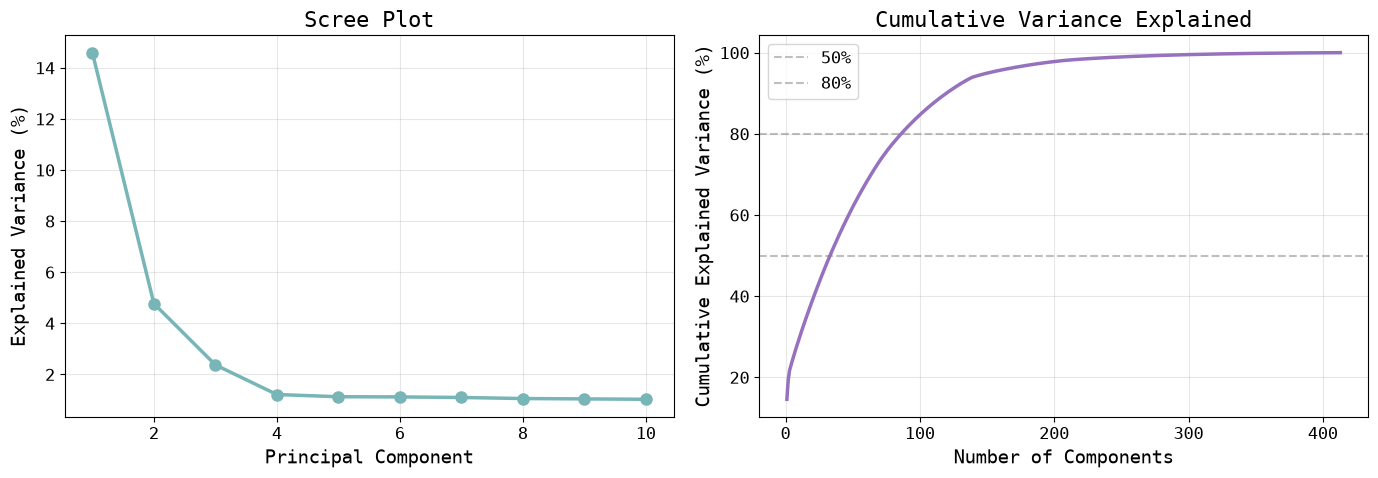

Saved: figures/pca_analysis/scree_plot.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree
axes[0].plot(range(1, 11), pca_full.explained_variance_ratio_[:10] * 100,
             'o-', color=COLORS[1], linewidth=2.5, markersize=8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot')
axes[0].grid(True, alpha=0.3)

# Cumulative
axes[1].plot(range(1, len(cumulative) + 1), cumulative,
             '-', color=COLORS[0], linewidth=2.5)
axes[1].axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='50%')
axes[1].axhline(y=80, color='gray', linestyle='--', alpha=0.5, label='80%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "scree_plot.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/pca_analysis/scree_plot.png")

## 4. PCA Stratified by Confound Variables

**Figure 4 (Manuscript):** Overlapping distributions across all confound variables confirm that demographic and technical factors do not drive the primary variance.

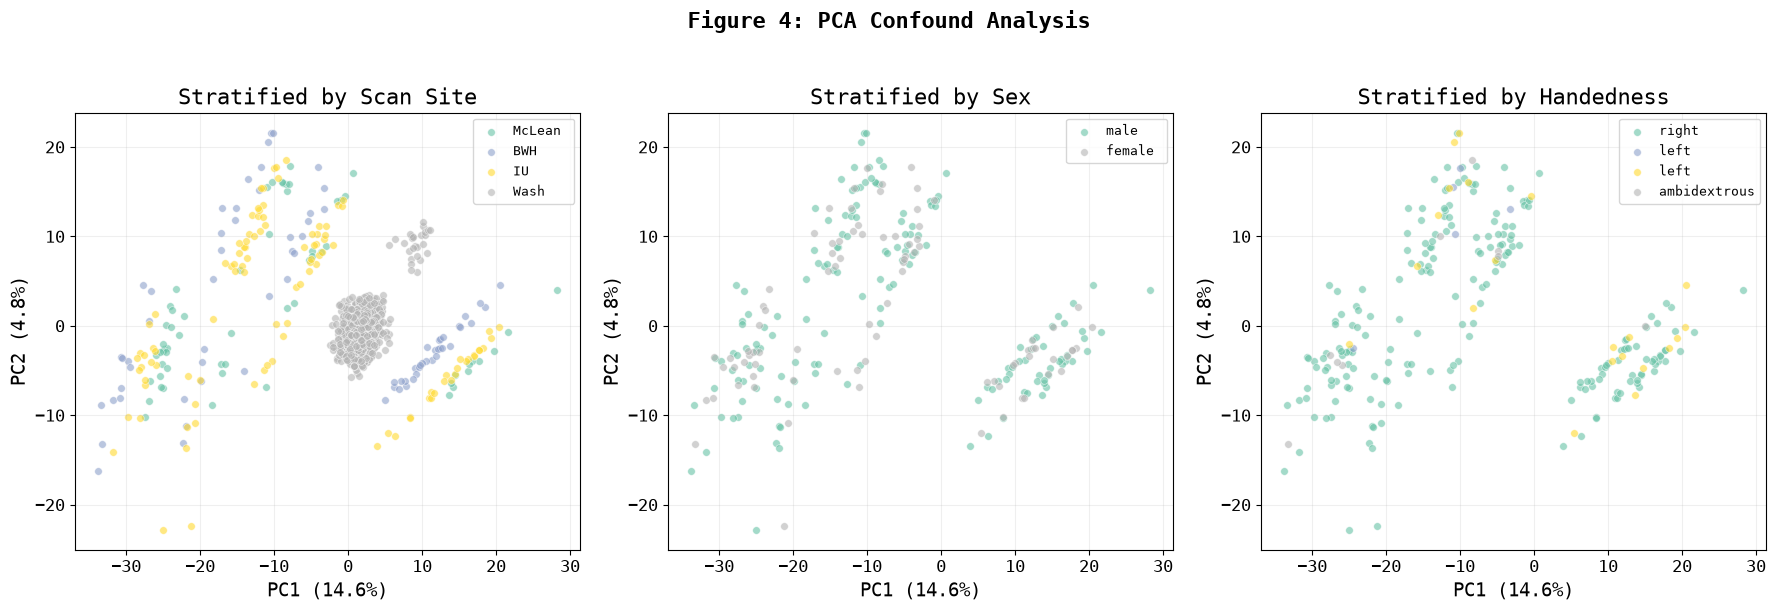

Saved: figures/pca_analysis/figure_4_confound_pca.png


In [5]:
confound_vars = [
    ('scan_site_text', 'Scan Site'),
    ('sex_label', 'Sex'),
    ('sub_handedness_label', 'Handedness')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (col, label) in zip(axes, confound_vars):
    categories = df[col].dropna().unique()
    colors = plt.cm.Set2(np.linspace(0, 1, len(categories)))

    for cat, color in zip(categories, colors):
        mask = df[col] == cat
        ax.scatter(df.loc[mask, 'PC1'], df.loc[mask, 'PC2'],
                   c=[color], label=cat, alpha=0.6, s=30, edgecolors='w', linewidth=0.5)

    ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}%)')
    ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}%)')
    ax.set_title(f'Stratified by {label}')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.2)

plt.suptitle('Figure 4: PCA Confound Analysis', fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "figure_4_confound_pca.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/pca_analysis/figure_4_confound_pca.png")

## 5. PCA by Diagnosis (Patient vs Control)

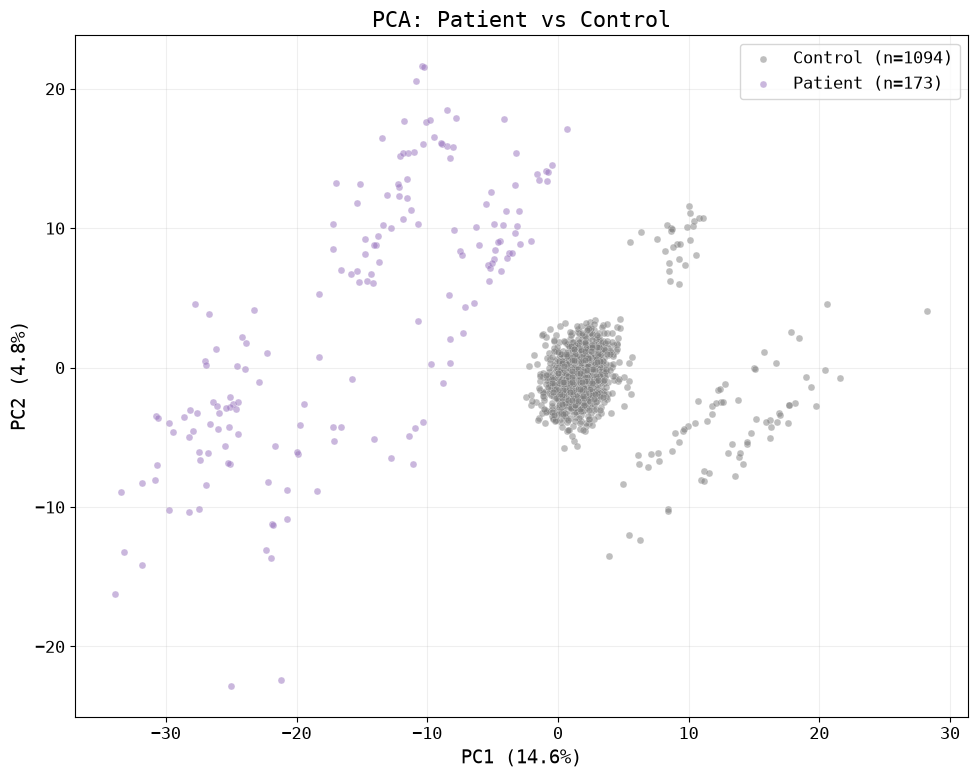


✓ PCA confound analysis complete.


In [6]:
fig, ax = plt.subplots(figsize=(10, 8))

colors_map = {'Control': '#7e7e7e', 'Patient': COLORS[0]}
for grp, color in colors_map.items():
    mask = df['diag_pvc'] == grp
    ax.scatter(df.loc[mask, 'PC1'], df.loc[mask, 'PC2'],
               c=color, label=f"{grp} (n={mask.sum()})",
               alpha=0.5, s=25, edgecolors='w', linewidth=0.3)

ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}%)')
ax.set_title('PCA: Patient vs Control')
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "pca_by_diagnosis.png"), dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ PCA confound analysis complete.")